Hiperparametre Ayarlama (Tuning) ve Overfitting Cozumu

Onceki deneyimizde LSTM modelinin egitim verisini ezberledigini (overfitting) 
ve test verisinde GRU'dan cok daha kotu sonuc verdigini gorduk. 

Bu notebook'ta **LSTM'i kurtarmak** ve modellerin basarisini artirmak icin sunlari deneyecegiz:
1. **Dropout Eklemek:** Nöronlarin belirli bir yuzdesini rastgele kapatarak ezberlemeyi onler.
2. **Kapasiteyi Dusurmek:** Gizli katman boyutunu (hidden_dim) azaltarak modelin ezberleme gucunu sinirlandiracagiz.
3. **Farkli Epoch Sayilari:** Egitimi daha erken durdurarak (early stopping mantigi) test basarisini artirmayi deneyecegiz.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import pickle
import math
from sklearn.metrics import mean_squared_error

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 5)

# 1. Tensorleri yukle
tensors = torch.load('../data/tensors.pt', weights_only=True)
x_train, y_train = tensors['x_train'], tensors['y_train']
x_test, y_test = tensors['x_test'], tensors['y_test']

# 2. Scaler yukle
with open('../data/scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)

# 3. Gercek degerleri bastan hazirla
y_train_actual = scaler.inverse_transform(y_train.numpy())
y_test_actual = scaler.inverse_transform(y_test.numpy())

print("Veriler hazir")
print(f"Egitim seti: {x_train.shape[0]} ornek")
print(f"Test seti  : {x_test.shape[0]} ornek")

Veriler hazir
Egitim seti: 2898 ornek
Test seti  : 724 ornek


In [2]:
class TunedLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, output_dim, dropout_rate=0.0):
        super(TunedLSTM, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        
        # Dropout parametresi eklendi
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, 
                            batch_first=True, dropout=dropout_rate if num_layers > 1 else 0)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).requires_grad_()
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).requires_grad_()
        out, (hn, cn) = self.lstm(x, (h0.detach(), c0.detach()))
        out = self.fc(out[:, -1, :])
        return out

class TunedGRU(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, output_dim, dropout_rate=0.0):
        super(TunedGRU, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        
        # Dropout parametresi eklendi
        self.gru = nn.GRU(input_dim, hidden_dim, num_layers, 
                          batch_first=True, dropout=dropout_rate if num_layers > 1 else 0)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).requires_grad_()
        out, (hn) = self.gru(x, (h0.detach()))
        out = self.fc(out[:, -1, :])
        return out

In [3]:
def train_and_evaluate(model, num_epochs, learning_rate=0.01):
    criterion = nn.MSELoss(reduction='mean')
    
    # Weight decay (L2 Regularization) da bir overfitting engelleyicidir
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-5)
    
    # Egitim
    model.train()
    for epoch in range(num_epochs):
        y_pred = model(x_train)
        loss = criterion(y_pred, y_train)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
    # Degerlendirme
    model.eval()
    with torch.no_grad():
        train_pred = model(x_train).numpy()
        test_pred = model(x_test).numpy()
        
    # Inverse transform ve RMSE
    train_pred_usd = scaler.inverse_transform(train_pred)
    test_pred_usd = scaler.inverse_transform(test_pred)
    
    train_rmse = math.sqrt(mean_squared_error(y_train_actual, train_pred_usd))
    test_rmse = math.sqrt(mean_squared_error(y_test_actual, test_pred_usd))
    
    return train_rmse, test_rmse, test_pred_usd

In [4]:
results = []
predictions = {}

print("Deneyler Basliyor...\n")

# --- BASELINE ---
print("1. Baseline egitiliyor (hidden=32, layers=2, epochs=100)...")
model_base = TunedLSTM(1, 32, 2, 1, dropout_rate=0.0)
tr_rmse, te_rmse, preds = train_and_evaluate(model_base, num_epochs=100)
results.append({'Model': 'Baseline LSTM', 'Train RMSE': tr_rmse, 'Test RMSE': te_rmse})
predictions['Baseline LSTM'] = preds

# --- SENARYO A ---
print("2. Senaryo A egitiliyor (hidden=16, layers=1, epochs=100)...")
model_a = TunedLSTM(1, 16, 1, 1, dropout_rate=0.0)
tr_rmse, te_rmse, preds = train_and_evaluate(model_a, num_epochs=100)
results.append({'Model': 'Senaryo A (Az Kapasite)', 'Train RMSE': tr_rmse, 'Test RMSE': te_rmse})
predictions['Senaryo A'] = preds

# --- SENARYO B ---
print("3. Senaryo B egitiliyor (hidden=32, layers=2, dropout=0.2, epochs=70)...")
model_b = TunedLSTM(1, 32, 2, 1, dropout_rate=0.2)
tr_rmse, te_rmse, preds = train_and_evaluate(model_b, num_epochs=70) # 100 yerine 70 epoch
results.append({'Model': 'Senaryo B (Dropout+Erken Durma)', 'Train RMSE': tr_rmse, 'Test RMSE': te_rmse})
predictions['Senaryo B'] = preds

print("\nDeneyler Bitti!")

Deneyler Basliyor...

1. Baseline egitiliyor (hidden=32, layers=2, epochs=100)...
2. Senaryo A egitiliyor (hidden=16, layers=1, epochs=100)...
3. Senaryo B egitiliyor (hidden=32, layers=2, dropout=0.2, epochs=70)...

Deneyler Bitti!


=== LSTM TUNING SONUCLARI ===
                          Model  Train RMSE  Test RMSE  Fark (Test - Train)
                  Baseline LSTM    3.164041  17.372706            14.208665
        Senaryo A (Az Kapasite)    3.458281  24.960132            21.501851
Senaryo B (Dropout+Erken Durma)    3.527152  18.887729            15.360577


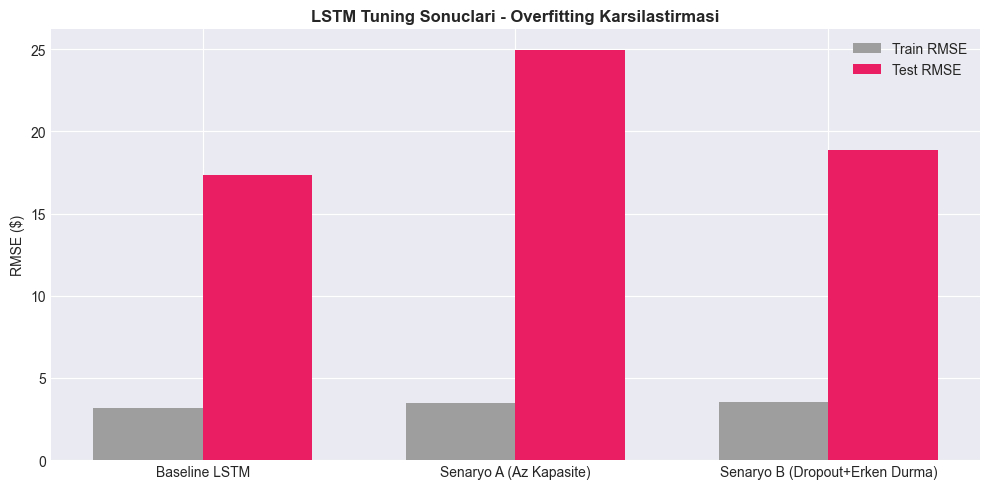

In [5]:
# Sonuclari DataFrame yapip gosterelim
df_results = pd.DataFrame(results)
df_results['Fark (Test - Train)'] = df_results['Test RMSE'] - df_results['Train RMSE']

print("=== LSTM TUNING SONUCLARI ===")
print(df_results.to_string(index=False))

# Gorsellestirme
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(df_results))
width = 0.35

ax.bar(x - width/2, df_results['Train RMSE'], width, label='Train RMSE', color='#9E9E9E')
ax.bar(x + width/2, df_results['Test RMSE'], width, label='Test RMSE', color='#E91E63')

ax.set_ylabel('RMSE ($)')
ax.set_title('LSTM Tuning Sonuclari - Overfitting Karsilastirmasi', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(df_results['Model'])
ax.legend()

plt.tight_layout()
plt.show()

In [6]:
print("GRU Dropout denemesi egitiliyor (hidden=32, layers=2, dropout=0.1, epochs=80)...")
model_gru_tuned = TunedGRU(1, 32, 2, 1, dropout_rate=0.1)
gru_tr, gru_te, gru_preds = train_and_evaluate(model_gru_tuned, num_epochs=80)

print(f"\nGRU Yeni Train RMSE: ${gru_tr:.2f}")
print(f"GRU Yeni Test RMSE : ${gru_te:.2f}")

GRU Dropout denemesi egitiliyor (hidden=32, layers=2, dropout=0.1, epochs=80)...

GRU Yeni Train RMSE: $2.83
GRU Yeni Test RMSE : $8.40


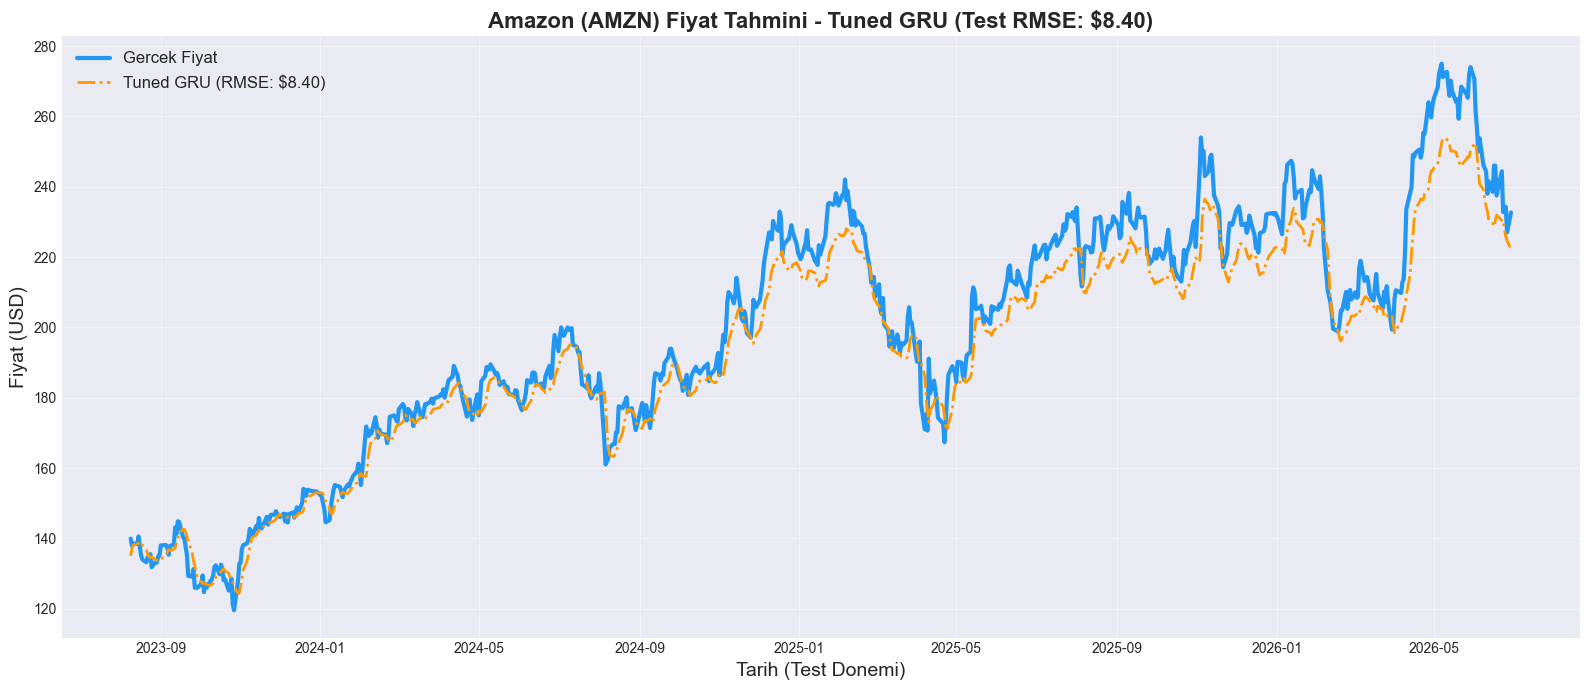

Grafik kaydedildi: results/prediction_gru_tuned.png
Model kaydedildi: data/model_gru_tuned.pt


In [7]:
# Orijinal verideki tarihleri almak icin data'yi okuyalim (sadece index'i)
data = pd.read_csv("../data/AMZN.csv", index_col=0, parse_dates=True)

# Lookback kadar gun bastan silinmisti
try:
    with open('../data/metadata.pkl', 'rb') as f:
        metadata = pickle.load(f)
    lookback = metadata['lookback']
except:
    lookback = 20

dates = data.index[lookback:]

# Test icin tarihleri ayir
split_point = len(y_train_actual)
test_dates = dates[split_point:]

# Tuned GRU Grafigi
fig, ax = plt.subplots(figsize=(16, 7))

# Sadece test tarihlerindeki gercek fiyat
ax.plot(test_dates, y_test_actual, color='#2196F3', linewidth=3, label='Gercek Fiyat')

# Yeni GRU Tahmini (gru_preds degiskeni onceki hucreden geliyor)
ax.plot(test_dates, gru_preds, color='#FF9800', linewidth=2, linestyle='-.',
        label=f'Tuned GRU (RMSE: ${gru_te:.2f})')

ax.set_title(f'Amazon (AMZN) Fiyat Tahmini - Tuned GRU (Test RMSE: ${gru_te:.2f})', fontsize=16, fontweight='bold')
ax.set_xlabel('Tarih (Test Donemi)', fontsize=14)
ax.set_ylabel('Fiyat (USD)', fontsize=14)
ax.legend(fontsize=12, loc='upper left')
ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig('../results/prediction_gru_tuned.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafik kaydedildi: results/prediction_gru_tuned.png")

# Modeli kaydet
torch.save(model_gru_tuned.state_dict(), '../data/model_gru_tuned.pt')
print("Model kaydedildi: data/model_gru_tuned.pt")